# Hands-on example notebook on how to use `py3DPDR` and run 1D models
This notebook shows how to compile and run `3D-PDR` in 1D models -including a grid of models- and plot the results

# Import py3DPDR
It automatically imports all necessary routines incuding plotting

In [2]:
import py3DPDR as pdr

# Create initial conditions: `pdr.ics()`

`py3DPDR` comes with the `pdr.ics()` function that allows to make initial conditions for one-dimensional PDR models. The initial conditions include uniform density clouds, the density, size, and resolution of which are defined by the user. The list of arguments is as follows:

|Variable|    Default|      Comments|
|--|--|--|
|nH        |   1000 |  Density of cloud (cm-3)|
|Avmax     |  10    |  Maximum Av (mag)|
|Avmin     |  1e-3  |  Minimum Av (mag)|
|resolution|  30    |  Resolution per Av dex|
|avfac     |  6.289e-22 |  Av factor (mag cm2)|
|directory |  ics/      |  Output directory|
|filename  |  outgrid.dat | Output filename |

If `pdr.ics()` is executed, with the above default values the function creates a 1D uniform density cloud of n=1e3 cm-3, with a minimum Av of 1e-3 mag, a maximum Av of 10 mag, a resolution of 30 points per Av dex (therefore from 1e-3 to 1e-2 there are 30 points logarithmically distributed, similarly from 1e-2 to 1e-1 etc.), using an Av factor of 6.289e-22 mag cm2 that converts the total H-nucleus column density to visual extinction. The output is written in the "ics/" directory and it is called "outgrid.dat".

If you want to save the file in a different directory, make sure the directory exists before `pdr.ics()` is executed.

## Example

The command

```python
pdr.ics(nH=2500, Avmax=20, resolution=40, filename='mymodel.dat')
```
creates a cloud with n=2500 cm-3 density, maximum Av of 20 mag and a higher resolution of 40 points per Av dex. All other values are equivalent to the above default values. The output "mymodel.dat" is written in the default "ics/" directory. This should be the input filename (`icsfile`) in the `params.dat` file to use it in the model ([see below](#pdrparams)).

In [2]:
pdr.ics(nH=2500, Avmax=20, resolution=40, filename='mymodel.dat')

File [ics/mymodel.dat] created


# Compile the 3D-PDR code: `pdr.makefile()`

To compile 3D-PDR, use the `pdr.makefile()`. Here, you can specify the flags to compile the code, as discussed in the manual. If a flag is not specified, the code will compile with the default flags. The default flags are as follows:

| Flag | Default value |
|--|--|
|F90|gfortran|
|CC|gcc|
|CPPFLAGS|-cpp|
|OPENMP|1|
|OPTIMISE|3|
|PYWRAP|1|
|DIMENSIONS|1 (do not change in py3DPDR)|
|RAYTHEIA|0 (do not change in py3DPDR)|
|XYZ|0 (do not change in py3DPDR)|
|NETWORK|REDUCED|
|XRAYS|0|
|DUST|HTT91|
|GUESS_TEMP|1|
|THERMALBALANCE|1|
|FORCECONVERGENCE|1|
|GRAINRECOMB|0|
|SUPRATHERMAL|0|
|H2FORM|CT02|
|CRATTENUATION|0|
|RESTART|0|
|OUTRAYINFO|0|


The code will not compile under `PYWRAP=1` and `DIMENSIONS=3` conditions. The purpose of this wrapper is to simplify the use of 3D-PDR in one-dimensional models only. 

## Examples

The command
```python
pdr.makefile(CC='gcc-14')
```
will compile the C part of the code using `gcc-14` (e.g. for Mac users).

The command
```python
pdr.makefile(GRAINRECOMB=1, SUPRATHERMAL=1)
```
will compile the code with all above flags but the `GRAINRECOMB` flag will change to `1` (switches on the electron recombination on dust grains) and the `SUPRATHERMAL` flag will also change to `1` (switches on the suprathermal formation of CO via CH+)

*Note:* Not all flags are printed on screen when `pdr.makefile()` is executed

In [3]:
pdr.makefile()

NETWORK = REDUCED
DUST = HTT91
THERMALBALANCE = 1
GRAINRECOMB = 0
SUPRATHERMAL = 0
H2FORM = CT02
CRATTENUATION = 0

Compiling 3D-PDR
Code compiled


# Specify the initial chemical abundances: `pdr.species()`

With the function `pdr.species()` the user can specify the initial abundances for the given network. The `network` variable is always needed to execute the function. The available variables are `REDUCED`, `MEDIUM` or `FULL` for the three available chemical networks. The default initial elemental abundances are those listed in Asplund+2009 paper, with the exception of oxygen (3e-4) and carbon (1.4e-4) abundances which are the local ISM depleted ones. The following table shows the variables and the default values.


|Variable    |    Default     |    Comments|
|--|--|--|
|Mg_plus    |     2.70E-07   |     Mg+|
|C_plus     |     1.40E-04   |     C+|
|He         |     1.00E-01   |     He|
|O          |     3.00E-04   |     O|
|H2         |     3.00E-01   |     H2|
|H          |     4.00E-01   |     H|
|N_plus     |     6.76E-05   |     N+|
|Na_plus    |     1.73E-06   |     Na+|
|F_plus     |     3.63E-08   |     F+|
|P_plus     |     2.57E-07   |     P+|
|S_plus     |     1.32E-05   |     S+|
|Fe_plus    |     3.16E-05   |     Fe+|
|Si_plus    |     3.23E-05   |     Si+|
|Cl_plus    |     3.16E-07   |     Cl+|


## Example
The command
```python
pdr.species(network='REDUCED', C_plus=1.40E-04, O=3.00E-04, Mg_plus=0)
```
creates the `species_reduced.d` file in the `chemfiles/` directory and sets C+=1.4e-5, O=3e-5, Mg=0 and all other species of the REDUCED network to the default values. 

In [4]:
pdr.species(network='REDUCED', C_plus=1.40E-04, O=3.00E-04, Mg_plus=0)

File 'chemfiles/species_reduced.d' successfully updated!


# Prepare the params.dat file: `pdr.params()`<a name='pdrparams' ></a>

You can specify all parameters of the PDR model from the `pdr.params()` function. The default values are as follows:


|Variable    |    Default |    Comments|
|--|--|--|
|-|*Input/Output - Densities* - |
|icsdir   |       ics        | Directory of initial conditions|
|icsfile  |       1Dn30.dat  | Initial conditions input filename|
|outdir   |       sims       | Output directory |
|prefix   |       model      | Output prefix|
|-|     *PDR parameters* -   |
|fuv      |       1          | Intensity of FUV radiation (Draine)|
|zcr      |       1.0E-17    | Cosmic-ray ionization rate (s-1)|
|xrays    |       0.0        | X-ray flux (erg/cm2/s)|
|d2g      |       1.0        | Dust-to-gas normalized to 1e-2|
|vturb    |       1.0        | Microturbulent velocity (km/s)|
|tend     |       1e7        | End chemical time (yr)|
|grainrad |       1.0E-5     | Grain radius (cm)|
|avfac     |      6.289e-22  | Av factor converting Ntot to Av|
|uvfac     |      3.02       | UV factor for FUV attenuation|
|redshift  |      0          | Redshift (controls Tcmb value)|
|av_crit   |      0.7        | Critical Av (for SUPRATHERMAL=1)|
|v_alfv    |      3.3        | Alfven velocity (km/s for SUPRATHERMAL=1)|
|-|*Ray-tracing parameters* - |
|healpix_level |  0          | Healpix level of refinment (DIMENSIONS=3)|
|theta_crit    |  1.3        | Theta_critical (DIMENSIONS=3, RAYTHEIA=0)|
|-|   *ODE Solver parameters* - |
|rel_tol    |     1.0E-8     | Relative tolerance parameter|
|abs_tol    |     1.0E-30    | Absolute tolerance parameter|
|-|   *Chemistry iterations* -  |
|init_iter  |     8          | Initial chemical iterations|
|max_iter   |     6000       | Maximum iterations over thermal balance|
|-|  *Thermal balance values* - |
|tgas       |     40.0       | Gas temperature (for THERMALBALANCE=0)|
|tfloor     |     2.725      | Floor tempearture (if tfloor<Tcmb, tfloor=Tcmb automatically)|
|tgas_max   |     30000.0    | Maximum allowed gas temperature|
|tdust      |     20.0       | Dust temperature (for DUST=0)|
|Fcrit      |     0.005      | Tolerance parameter for thermal balance convrence|
|Tdiff      |     0.01       | Maximum temperature difference for thermal balance convergence|


## Example

The command
```python
pdr.params(icsfile='mymodel.dat', prefix='mymodel', fuv=10, zcr=1e-17)
```
creates the parameters to run a model with initial conditions specified by the `output.dat` of the `ics/` directory. The output prefix is called `mymodel` in the `sims/` directory. The FUV intensity is 10 Draine, the cosmic-ray ionization rate is 1e-15 s-1. All other variables are the above default ones.

In [5]:
pdr.params(icsfile='mymodel.dat', prefix='mymodel', fuv=10, zcr=1e-17)

File [params.dat] updated


# Adding a new coolant

To add a new coolant, use the `coolant_files=["COOLFILE"]` argument within the `pdr.params()` function, where COOLFILE is the filename of the coolant in the `chemfiles/` directory. This argument is a list, so you need to include it in [ ]. Currently, the available additional coolants are the following.

| Coolant | coolant name (COOLFILE) | 
|--|--|
|CN|cn.dat|
|HCN|hcn.dat|
|HNC|hnc.dat|
|HCO+|hcop.dat|
|N2H+|n2h+.dat|
|OH|oh.dat|
|SiO|sio-h2.dat|

## Example

```python
pdr.params(icsfile='mymodel.dat', prefix='mymodel', fuv=10, coolant_files=['hcop.dat'])
```
creates the params.dat file discussed above and adds the HCO+ coolant at the end. Note that the standard coolants (12CO, C+, C, 16O) are always added by default.

In [6]:
pdr.params(icsfile='mymodel.dat', prefix='mymodel', fuv=10, coolant_files=['hcop.dat'])

File [params.dat] updated


# Using the `CRATTENUATION=1` flag

If you have compiled the code with `CRATTENUATION=1`, you will need to select either `L` or `H` in the `zcr` variable. 

## Example

```python
pdr.params(icsfile='mymodel.dat',prefix='mymodel',zcr='H')
```
uses the H attenuation function (see Padovani+ 2018, A&A, 614, 111). In case you have compiled the code with `CRATTENUATION=0` and use `zcr="H"` (or "L"), the code will not run.

In [21]:
pdr.params(icsfile='mymodel.dat',prefix='mymodel',zcr='H')

File [params.dat] updated


# Run the code: `pdr.run3DPDR()`<a name='pdrrun3DPDR' ></a>

The command 
```python
pdr.run3DPDR()
```
runs the code. The code requires from a few seconds to several minutes depending on your machine and the chosen PDR configuration to converge.


In [3]:
pdr.run3DPDR()

Running 3D-PDR. Check terminal for status
Simulation finished


# Plot PDR results: `pdr.plot()`<a name='pdrplot' ></a>

The function `pdr.plot()` offers the ability to quickly plot results for a particular model. It is *by no means* written to create paper-quality plots and perform more advanced calculations / comparisons. There is an extended list of available arguments for that function, shown below:


|argument |       Comments|
|--|--|
|x            |   position of element (pc)|
|Av           |   visual extinction (mag)|
|Tgas         |   gas temperature (K)|
|Tdust        |   dust temperature (K)|
|nH           |   total H-nucleus number density (cm-3)|
|fuv          |   intensity of FUV radiation (Draine)|
|photoelectric |  Photoelectric heating (erg/cm3/s)|
|Cionization   |  Carbon ionization heating (erg/cm3/s)|
|H2formation   |  H2 formation heating (erg/cm3/s)|
|H2photodis    |  H2 photodissociation heating (erg/cm3/s)|
|FUVpumping    |  FUV pumping heating (erg/cm3/s)|
|cosmicray     |  cosmic-ray heating (erg/cm3/s)|
|turbulent     |  turbulent heating (erg/cm3/s)|
|chemical      |  chemical heating (erg/cm3/s)|
|gasgrain      |  gas-grain heating (erg/cm3/s)|
|totheat       |  Total heating (erg/cm3/s)|
|COcool        |  CO cooling (erg/cm3/s)|
|C+cool        |  C+ cooling (erg/cm3/s)|
|Ccool         |  C cooling (erg/cm3/s)|
|Ocool         |  O cooling (erg/cm3/s)|
|any additional coolants here||
|totcool       |  Total cooling (erg/cm3/s)|

where the additional coolants included in the params.dat file (e.g. HCO+ with `hcop.dat`), follow the notation COOLANT+cool e.g. for HCO+ it will be `HCO+cool`. Note that `gasgrain` heating can also receive negative values at which point it becomes a cooling function. Other arguments include:

|Variable|      Default    |     Comments|
|--|--|--|
|linestyle |      -      |         Linestyle as in matplotlib|
|directory |      sims/  |         Specifies model output directory|
|prefix    |      None   |         Prefix of model to plot|
|scale     |      loglog |         linear, loglog, semilogx, semilogy|


In addition, the abundance of any species can be plotted by using the name of the species in the function, as defined in the `species_NETWORK.d` chemical network file.

## Example 1

```python
pdr.plot("Av","Tgas",scale="semilogx")
```
plots the gas temperature versus Av on a semi-log scale (log in x axis)

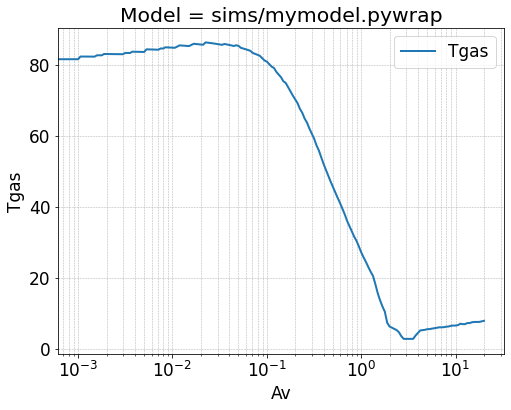

In [8]:
pdr.plot("Av","Tgas",scale="semilogx", prefix="mymodel")

## Example 2

```python
pdr.plot("Av","e-",scale="loglog",prefix="mymodel")
```
plots the electron abundance versus Av in log-log scale

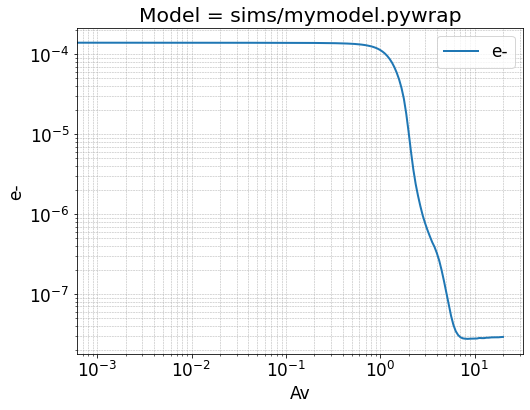

In [9]:
pdr.plot("Av","e-",scale="loglog",prefix="mymodel")

## Example 3

It is possible to plot two or more species simultaneously
```python
pdr.plot("Av",["H","H2"],scale="loglog",prefix="mymodel")
```
for the HI-to-H2 transition

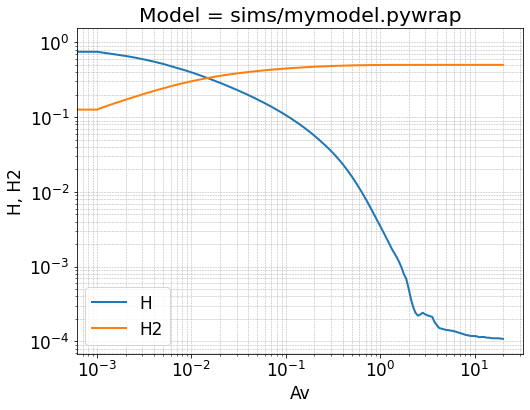

In [10]:
pdr.plot("Av",["H","H2"],scale="loglog",prefix="mymodel")

## Example 4

```python
pdr.plot("Av",["C+","C","CO"],scale="loglog",prefix="mymodel")
```
Plots the carbon cycle (C+, C, CO)

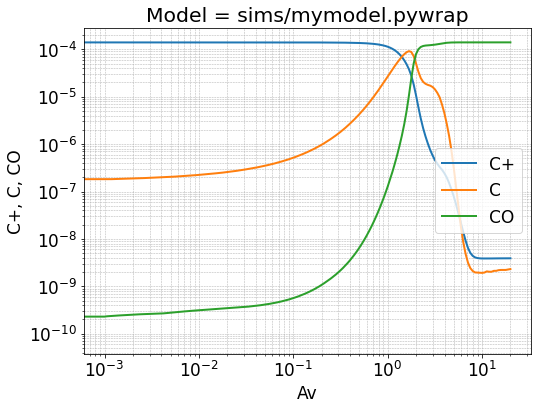

In [11]:
pdr.plot("Av",["C+","C","CO"],scale="loglog",prefix="mymodel")

## Example 5

```python
pdr.plot("Av",["HCO+"],scale="loglog",prefix="mymodel")
```
Plots the HCO+ abundance

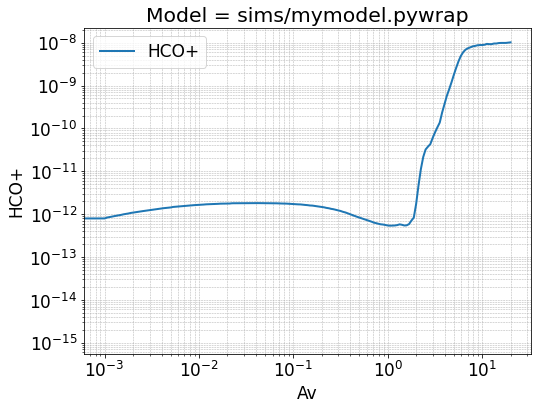

In [12]:
pdr.plot("Av",["HCO+"],scale='loglog',prefix='mymodel')

## Example 6

```python
pdr.plot("Av",["totheat","totcool"],scale="loglog",prefix='mymodel')
```
plots the total heating and total cooling functions in a log-log scale. Under the THERMALBALANCE=1 flag, these two curves should match.

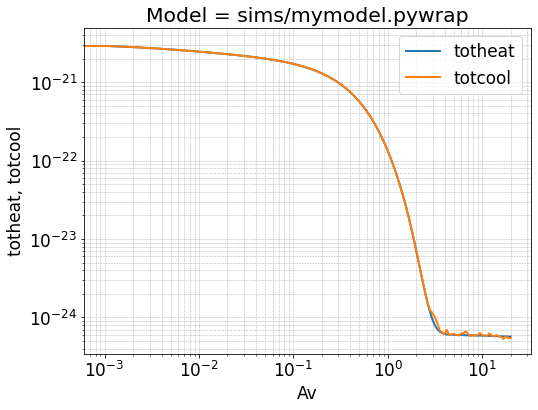

In [13]:
pdr.plot("Av",["totheat","totcool"],scale="loglog",prefix='mymodel')

# Running a grid of models

It is possible to generate a grid of uniform density distributions and run them for different combinations of ISM environmental parameters.

**CAUTION:** Running the following block requires an extended period of time, please be patient!

The command `pdr.makefile()` is not necessary to be called within the loop since we can compile the code once and use it for all models. 

Similarly, if you use the same chemical network and metallicity for the grid of models, you do not need to include `pdr.species()` in the loop.

## After the grid has finished

All outputs will be stored in the sims/ directory (or the one you have manually specified). At this point you may use your own algorithms for data analysis and plotting.

In [16]:
nH_input = [1e2,1e3,1e4] #1e2, 1e3, 1e4 cm-3 uniform density slabs
Avmax_input = 10
Avmin_input = 1e-3
resolution_input = 30

FUV = [1,1e1,1e2] #1, 10, 100 Draine intensity
ZCR = [1e-17, 1e-16, 1e-15] #CR ionization rate

for i in range(len(nH_input)):
    pdr.ics(nH = nH_input[i], Avmax = Avmax_input, Avmin = Avmin_input, resolution = resolution_input)
    for j in range(len(FUV)):
        for k in range(len(ZCR)):
            pdr.params(icsfile='outgrid.dat', prefix='grid_'+str(i)+'_'+str(j)+'_'+str(k),
                      fuv=FUV[j], zcr=ZCR[k])
            pdr.run3DPDR()


File [ics/outgrid.dat] created
File [params.dat] updated
Running 3D-PDR. Check terminal for status
Simulation finished
File [params.dat] updated
Running 3D-PDR. Check terminal for status
Simulation finished
File [params.dat] updated
Running 3D-PDR. Check terminal for status
Simulation finished
File [params.dat] updated
Running 3D-PDR. Check terminal for status
Simulation finished
File [params.dat] updated
Running 3D-PDR. Check terminal for status
Simulation finished
File [params.dat] updated
Running 3D-PDR. Check terminal for status
Simulation finished
File [params.dat] updated
Running 3D-PDR. Check terminal for status
Simulation finished
File [params.dat] updated
Running 3D-PDR. Check terminal for status
Simulation finished
File [params.dat] updated
Running 3D-PDR. Check terminal for status
Simulation finished
File [ics/outgrid.dat] created
File [params.dat] updated
Running 3D-PDR. Check terminal for status
Simulation finished
File [params.dat] updated
Running 3D-PDR. Check terminal f